# UV coverage, dirty image, dirty beam

Same dark/serif aesthetic as the figure below, for the raw inputs to the
simple deconvolution pipeline: the (u, v) sampling from
`data/ngc7469_co21.ms`, and the central channel of the CASA-gridded dirty
image and dirty beam (`simple_results/data/dirty.npy` / `psf.npy`) that
pipeline runs on.

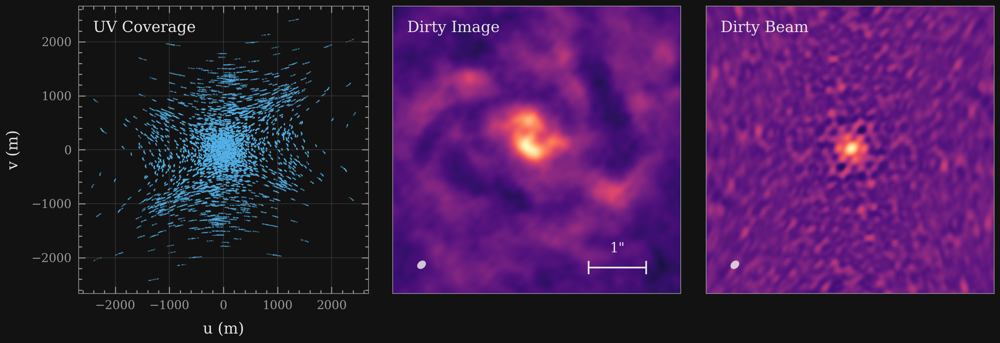

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib import patheffects as pe
from matplotlib.colors import AsinhNorm
from casatools import table

SURFACE = "#121212"
INK = "#e6e6e6"
MUTED = "#9a9a9a"
COLOR_UV = "#56B4E9"
LABEL_OUTLINE = [pe.withStroke(linewidth=3, foreground=SURFACE)]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "text.color": INK,
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": MUTED, "font.size": 15, "font.family": "serif",
    "xtick.direction": "in", "ytick.direction": "in",
})

DATA_DIR = "simple_results/data"
CELL_ARCSEC = 0.04
WIDTH_KMS = 5.0

t = table()
t.open("data/ngc7469_co21.ms")
uvw = t.getcol("UVW")            # shape (3, nrows)
flag_row = t.getcol("FLAG_ROW")
t.close()

good = ~flag_row
u_m, v_m = uvw[0][good], uvw[1][good]
rng = np.random.default_rng(0)
idx = rng.choice(len(u_m), size=min(40000, len(u_m)), replace=False)
u_s, v_s = u_m[idx], v_m[idx]

psf = np.load(f"{DATA_DIR}/psf.npy")
dirty = np.load(f"{DATA_DIR}/dirty.npy")
bmaj, bmin, bpa = np.load(f"{DATA_DIR}/beam_arcsec_deg.npy")
chan = psf.shape[0] // 2
psf_chan = psf[chan]                          # PSF has no meaningful moment 0
dirty_mom0 = np.sum(dirty, axis=0) * WIDTH_KMS

# The PSF's main lobe (peak 1.0) swamps a linear scale -- its sidelobes are
# only a few % of that. A hard clip at the sidelobe amplitude flattens the
# whole main lobe to one saturated color, hiding its shape -- an asinh
# stretch instead compresses the huge peak-to-sidelobe dynamic range while
# staying monotonic, so the lobe's Gaussian falloff *and* the faint
# sidelobe ripples both stay visible on the same (linear-looking) map.
sidelobe_scale = np.percentile(np.abs(psf_chan[psf_chan < 0.5]), 99.5)
psf_norm = AsinhNorm(linear_width=sidelobe_scale, vmin=-3 * sidelobe_scale, vmax=1.0)

ny, nx = psf_chan.shape
extent = np.array([nx, -nx, -ny, ny]) / 2.0 * CELL_ARCSEC  # RA flips
BEAM_CENTER = (2.0, -2.0)

fig, (ax_uv, ax_dirty, ax_psf) = plt.subplots(1, 3, figsize=(16.5, 5.5),
                                              constrained_layout=True)

# --- UV coverage ---
ax_uv.scatter(u_s, v_s, s=2, alpha=0.25, color=COLOR_UV, linewidths=0)
ax_uv.scatter(-u_s, -v_s, s=2, alpha=0.25, color=COLOR_UV, linewidths=0)
ax_uv.set_box_aspect(1)
ax_uv.set_aspect("equal", adjustable="box")
ax_uv.set_xlabel("u (m)", fontsize=18, labelpad=12)
ax_uv.set_ylabel("v (m)", fontsize=18, labelpad=12)
ax_uv.grid(True, color=MUTED, alpha=0.25, linewidth=0.8)
ax_uv.set_axisbelow(True)
ax_uv.tick_params(which="both", direction="in", top=True, bottom=True,
                  left=True, right=True, length=8, width=1.2, labelsize=14,
                  pad=8)
ax_uv.minorticks_on()
ax_uv.tick_params(which="minor", length=4)
for spine in ax_uv.spines.values():
    spine.set_color(MUTED)
ax_uv.text(0.05, 0.95, "UV Coverage", transform=ax_uv.transAxes, ha="left",
          va="top", color=INK, fontsize=18, path_effects=LABEL_OUTLINE)

# --- dirty image (moment 0) / dirty beam (central channel, sidelobe-scaled) ---
image_panels = [
    (ax_dirty, dirty_mom0, "Dirty Image", "magma",
     dict(vmin=dirty_mom0.min(), vmax=dirty_mom0.max())),
    (ax_psf, psf_chan, "Dirty Beam", "magma", dict(norm=psf_norm)),
]
for ax, cube, label, cmap, norm_kwargs in image_panels:
    ax.imshow(cube, origin="lower", extent=extent, cmap=cmap,
             interpolation="bilinear", **norm_kwargs)
    ax.set_xlim(2.5, -2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(1)
    for spine in ax.spines.values():
        spine.set_color(MUTED)
    ax.text(0.05, 0.95, label, transform=ax.transAxes, ha="left", va="top",
           color=INK, fontsize=18)
    beam_patch = Ellipse(BEAM_CENTER, width=bmin, height=bmaj, angle=-bpa,
                         facecolor=INK, edgecolor="none", alpha=0.85)
    ax.add_patch(beam_patch)

bar_x_center, bar_y = -1.4, -2.05
bar_half_len, cap_half_h, label_pad = 0.5, 0.10, 0.22
x0, x1 = bar_x_center - bar_half_len, bar_x_center + bar_half_len
ax_dirty.plot([x0, x1], [bar_y, bar_y], color=INK, linewidth=2, solid_capstyle="butt")
ax_dirty.plot([x0, x0], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax_dirty.plot([x1, x1], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax_dirty.text(bar_x_center, bar_y + label_pad, '1"', color=INK,
             ha="center", va="bottom", fontsize=16)

plt.show()

saved simple_results/data/dirty_beam.npy: (320, 320) at 0.04"/px (12.80" across), peak 1.0000


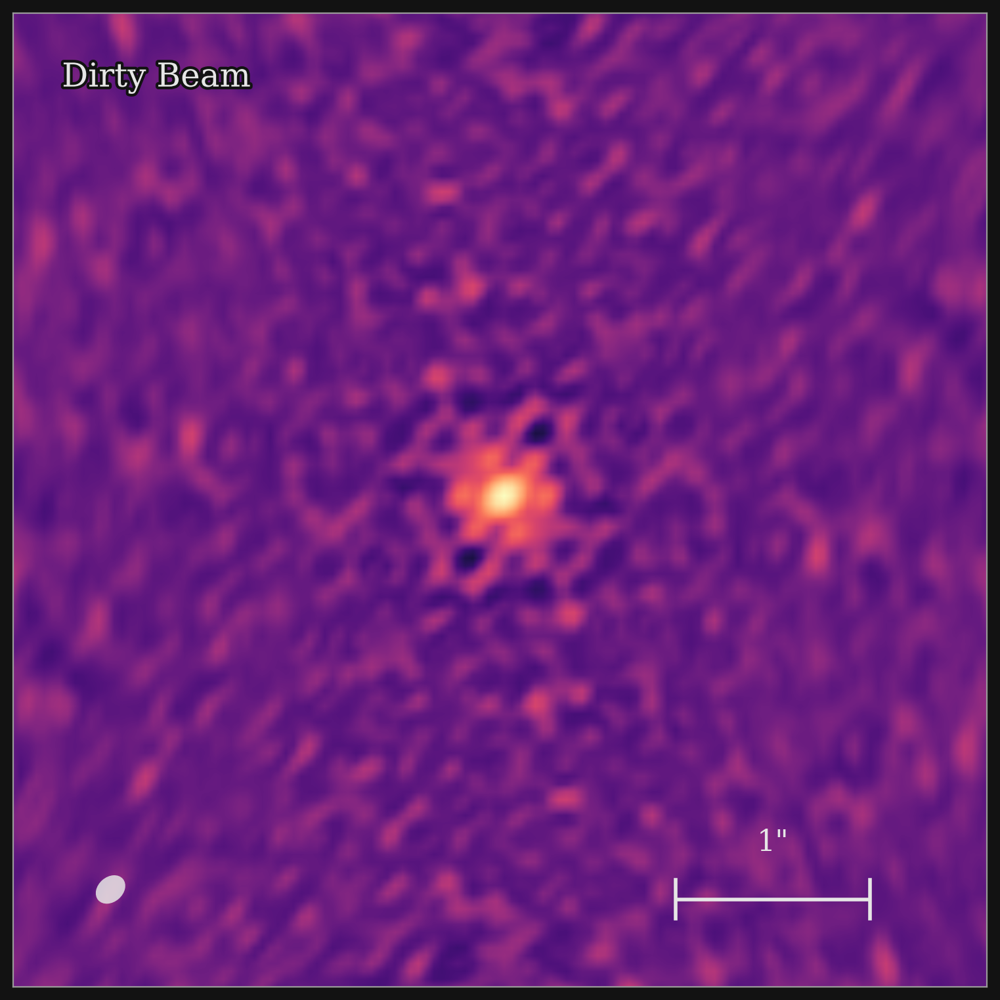

In [2]:
# Dirty beam on its own, same asinh stretch as the panel above (so the main
# lobe's falloff and the few-percent sidelobes stay visible together), with a
# scale bar in arcsec. The 2-D central-channel beam is also saved to disk for
# reuse elsewhere.
beam_path = f"{DATA_DIR}/dirty_beam.npy"
np.save(beam_path, psf_chan)
print(f'saved {beam_path}: {psf_chan.shape} at {CELL_ARCSEC}"/px '
      f'({psf_chan.shape[1] * CELL_ARCSEC:.2f}" across), peak {psf_chan.max():.4f}')

fig, ax = plt.subplots(figsize=(7.5, 7.5), constrained_layout=True)

ax.imshow(psf_chan, origin="lower", extent=extent, cmap="magma",
          norm=psf_norm, interpolation="bilinear")
ax.set_xlim(2.5, -2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_box_aspect(1)
for spine in ax.spines.values():
    spine.set_color(MUTED)
ax.text(0.05, 0.95, "Dirty Beam", transform=ax.transAxes, ha="left", va="top",
        color=INK, fontsize=18, path_effects=LABEL_OUTLINE)

ax.add_patch(Ellipse(BEAM_CENTER, width=bmin, height=bmaj, angle=-bpa,
                     facecolor=INK, edgecolor="none", alpha=0.85))

BAR_ARCSEC = 1.0
bar_x_center, bar_y = -1.4, -2.05
cap_half_h, label_pad = 0.10, 0.22
x0, x1 = bar_x_center - BAR_ARCSEC / 2, bar_x_center + BAR_ARCSEC / 2
ax.plot([x0, x1], [bar_y, bar_y], color=INK, linewidth=2, solid_capstyle="butt")
ax.plot([x0, x0], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax.plot([x1, x1], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax.text(bar_x_center, bar_y + label_pad, f'{BAR_ARCSEC:g}"', color=INK,
        ha="center", va="bottom", fontsize=16)

plt.show()

# Moment 0 and spectrum: model convolved with full / half / quarter beam

Sparse model from the simple deconvolution pipeline
(`simple_results/data/model.npy`), convolved with three Gaussian beams --

- **full beam** -- the actual CLEAN restoring beam (0.167" x 0.128", PA
  -49.1 deg)
- **half beam** -- the same beam at half that FWHM (0.084" x 0.064")
- **quarter beam** -- at a quarter that FWHM (0.042" x 0.032")

None of the three has a residual or noise added -- each is the model alone,
convolved. Each moment-0 map is normalized to its own peak (0-100%), so the
panels compare recovered *shape*, not absolute flux. The spectrum panel adds
the dirty cube's own spatially-integrated spectrum for reference, each curve
also normalized to its own peak.

In [3]:
import sys
import numpy as np
from scipy.signal import fftconvolve

sys.path.insert(0, "src")
from fista_2d1d import gaussian_beam

DATA_DIR = "simple_results/data"
CELL_ARCSEC = 0.04   # matches legacy/simple/grid_with_casa.py's CELL_ARCSEC
WIDTH_KMS = 5.0       # matches grid_with_casa.py's WIDTH_KMS
START_KMS = 4610.0    # matches grid_with_casa.py's START_KMS
NCHAN = 90            # matches grid_with_casa.py's NCHAN

model = np.load(f"{DATA_DIR}/model.npy")
dirty = np.load(f"{DATA_DIR}/dirty.npy")
bmaj, bmin, bpa = np.load(f"{DATA_DIR}/beam_arcsec_deg.npy")

def convolve_beam(model, bmaj_arcsec, bmin_arcsec, bpa_deg):
    beam_pix = gaussian_beam(model.shape[1:], bmaj_arcsec / CELL_ARCSEC,
                             bmin_arcsec / CELL_ARCSEC, bpa_deg)
    out = np.empty_like(model)
    for k in range(model.shape[0]):
        out[k] = fftconvolve(model[k], beam_pix, mode="same")
    return out

beams = {
    "full": (bmaj, bmin),
    "half": (bmaj / 2.0, bmin / 2.0),
    "quarter": (bmaj / 4.0, bmin / 4.0),
}
cubes = {name: convolve_beam(model, bm, bn, bpa) for name, (bm, bn) in beams.items()}

mom0 = {name: np.sum(cube, axis=0) * WIDTH_KMS for name, cube in cubes.items()}
norm_mom0 = {name: m / m.max() * 100.0 for name, m in mom0.items()}

ny, nx = model.shape[1:]
extent = np.array([nx, -nx, -ny, ny]) / 2.0 * CELL_ARCSEC  # RA flips

velocity = START_KMS + np.arange(NCHAN) * WIDTH_KMS
spectra = {name: cube.sum(axis=(1, 2)) for name, cube in cubes.items()}
spectra["dirty"] = dirty.sum(axis=(1, 2))
norm_spectra = {name: s / np.abs(s).max() for name, s in spectra.items()}

for name, (bm, bn) in beams.items():
    print(f"{name} beam: {bm:.4f}\" x {bn:.4f}\" @ {bpa:.1f} deg")

full beam: 0.1671" x 0.1279" @ -49.1 deg
half beam: 0.0835" x 0.0640" @ -49.1 deg
quarter beam: 0.0418" x 0.0320" @ -49.1 deg


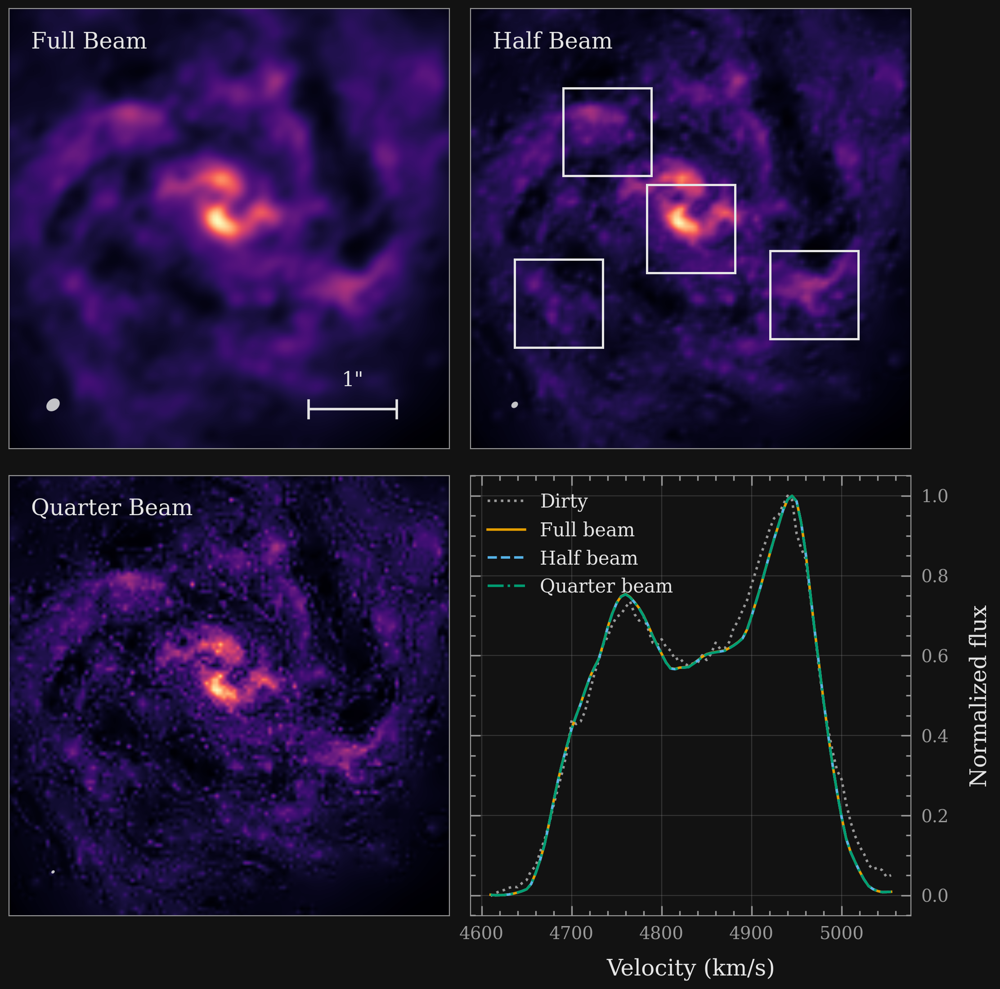

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle

SURFACE = "#121212"
INK = "#e6e6e6"
MUTED = "#9a9a9a"

# Okabe-Ito colorblind-safe categorical set.
COLOR_DIRTY, COLOR_FULL, COLOR_HALF, COLOR_QUARTER = (
    "#999999", "#E69F00", "#56B4E9", "#009E73",
)

# Same four regions used by the region-cutout figures below.
REGIONS = [
    ("Nucleus", 0.00, 0.00),
    ("Upper Arm", 0.95, 1.10),
    ("Left Clump", 1.50, -0.85),
    ("Right Clump", -1.40, -0.75),
]
BOX_HALF = 0.5  # arcsec

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "text.color": INK,
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": MUTED, "font.size": 15, "font.family": "serif",
    "xtick.direction": "in", "ytick.direction": "in",
})

cmap = "magma"
fig, axes = plt.subplots(2, 2, figsize=(11, 11), constrained_layout=True)
ax_full, ax_half = axes[0, 0], axes[0, 1]
ax_quarter, ax_spec = axes[1, 0], axes[1, 1]

image_panels = [
    (ax_full, "full", "Full Beam"),
    (ax_half, "half", "Half Beam"),
    (ax_quarter, "quarter", "Quarter Beam"),
]

# bottom-left "beam" corner is at data (x=+2.0, y=-2.0) -- x increases to
# the left on screen because RA runs East-to-West (set_xlim below is
# reversed), so a *positive* x sits at the visual left edge.
BEAM_CENTER = (2.0, -2.0)

for ax, name, label in image_panels:
    ax.imshow(norm_mom0[name], origin="lower", extent=extent, cmap=cmap,
             vmin=norm_mom0[name].min(), vmax=norm_mom0[name].max(),
             interpolation="bilinear")
    ax.set_xlim(2.5, -2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(1)
    for spine in ax.spines.values():
        spine.set_color(MUTED)
    ax.text(0.05, 0.95, label, transform=ax.transAxes, ha="left", va="top",
           color=INK, fontsize=18)

    bm, bn = beams[name]
    beam_patch = Ellipse(BEAM_CENTER, width=bn, height=bm, angle=-bpa,
                         facecolor=INK, edgecolor="none", alpha=0.85)
    ax.add_patch(beam_patch)

for _, cx, cy in REGIONS:
    ax_half.add_patch(Rectangle((cx - BOX_HALF, cy - BOX_HALF), 2 * BOX_HALF, 2 * BOX_HALF,
                                edgecolor=INK, facecolor="none", linewidth=1.8))

ax_full.sharex(ax_full)
ax_half.sharex(ax_full)
ax_quarter.sharex(ax_full)
ax_half.sharey(ax_full)
ax_quarter.sharey(ax_full)

# Scale bar (visual bottom-right of the first panel, data x negative for
# the same RA-flip reason as BEAM_CENTER above): a horizontal line with
# small vertical end caps, and the "1'" label above it with a bit of
# padding.
bar_x_center, bar_y = -1.4, -2.05
bar_half_len, cap_half_h, label_pad = 0.5, 0.10, 0.22
x0, x1 = bar_x_center - bar_half_len, bar_x_center + bar_half_len

ax_full.plot([x0, x1], [bar_y, bar_y], color=INK, linewidth=2, solid_capstyle="butt")
ax_full.plot([x0, x0], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax_full.plot([x1, x1], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax_full.text(bar_x_center, bar_y + label_pad, '1"', color=INK,
            ha="center", va="bottom", fontsize=16)

series = [
    ("dirty", "Dirty", COLOR_DIRTY, ":"),
    ("full", "Full beam", COLOR_FULL, "-"),
    ("half", "Half beam", COLOR_HALF, "--"),
    ("quarter", "Quarter beam", COLOR_QUARTER, "-."),
]
for name, label, color, style in series:
    ax_spec.plot(velocity, norm_spectra[name], linestyle=style, color=color,
                linewidth=2, label=label)

ax_spec.set_box_aspect(1)
ax_spec.set_xlabel("Velocity (km/s)", fontsize=18, labelpad=12)
ax_spec.set_ylabel("Normalized flux", fontsize=18, labelpad=16)
ax_spec.yaxis.set_label_position("right")
ax_spec.grid(True, color=MUTED, alpha=0.25, linewidth=0.8)
ax_spec.set_axisbelow(True)
ax_spec.tick_params(which="both", direction="in", top=True, bottom=True,
                    left=True, right=True, labelleft=False, labelright=True,
                    length=8, width=1.2, labelsize=14, pad=8)
ax_spec.tick_params(which="minor", length=4)
ax_spec.minorticks_on()
for spine in ax_spec.spines.values():
    spine.set_color(MUTED)

legend = ax_spec.legend(loc="upper left", frameon=False, fontsize=15)
plt.setp(legend.get_texts(), color=INK)

plt.show()

# Region cutouts: full / half / quarter beam

Four 1" cutouts from the moment-0 maps above -- the nucleus and three
off-nuclear clumps -- side by side across the three beam sizes, a closer
look at how much extra structure the smaller beams recover in each region.
Same percent-of-peak (0-100%) normalization as the full-field maps.

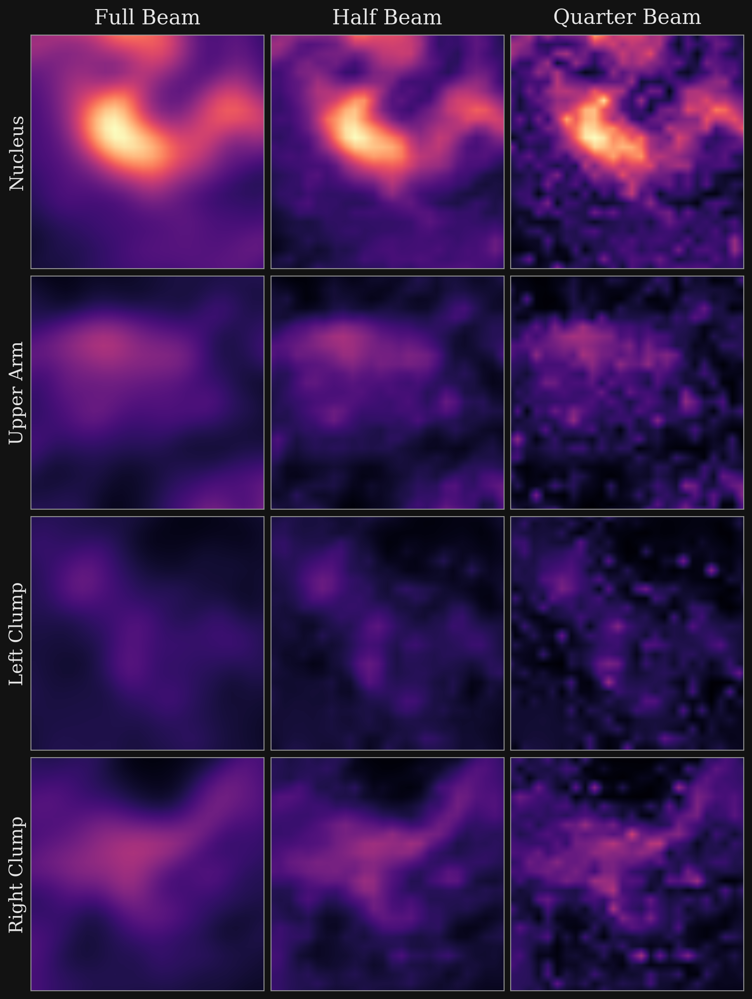

In [6]:
import matplotlib.pyplot as plt

REGIONS = [
    ("Nucleus", 0.00, 0.00),
    ("Upper Arm", 0.95, 1.10),
    ("Left Clump", 1.50, -0.85),
    ("Right Clump", -1.40, -0.75),
]
BOX_HALF = 0.5  # arcsec
beam_cols = [("full", "Full Beam"), ("half", "Half Beam"), ("quarter", "Quarter Beam")]

fig, axes = plt.subplots(4, 3, figsize=(9, 12), constrained_layout=True)

for row, (region_name, cx, cy) in enumerate(REGIONS):
    for col, (key, title) in enumerate(beam_cols):
        ax = axes[row, col]
        ax.imshow(norm_mom0[key], origin="lower", extent=extent, cmap="magma",
                 vmin=0, vmax=100, interpolation="bilinear")
        ax.set_xlim(cx + BOX_HALF, cx - BOX_HALF)
        ax.set_ylim(cy - BOX_HALF, cy + BOX_HALF)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_box_aspect(1)
        for spine in ax.spines.values():
            spine.set_color(MUTED)
        if row == 0:
            ax.set_title(title, fontsize=18, pad=10)
        if col == 0:
            ax.set_ylabel(region_name, fontsize=16)

plt.show()

# Region cutouts with context: where each cutout comes from

Same four regions, but with a leading "Location" column -- the full
half-beam moment-0 map with a patch outlining exactly where that row's 1"
cutout sits -- so the crops above can be traced back to the full field.

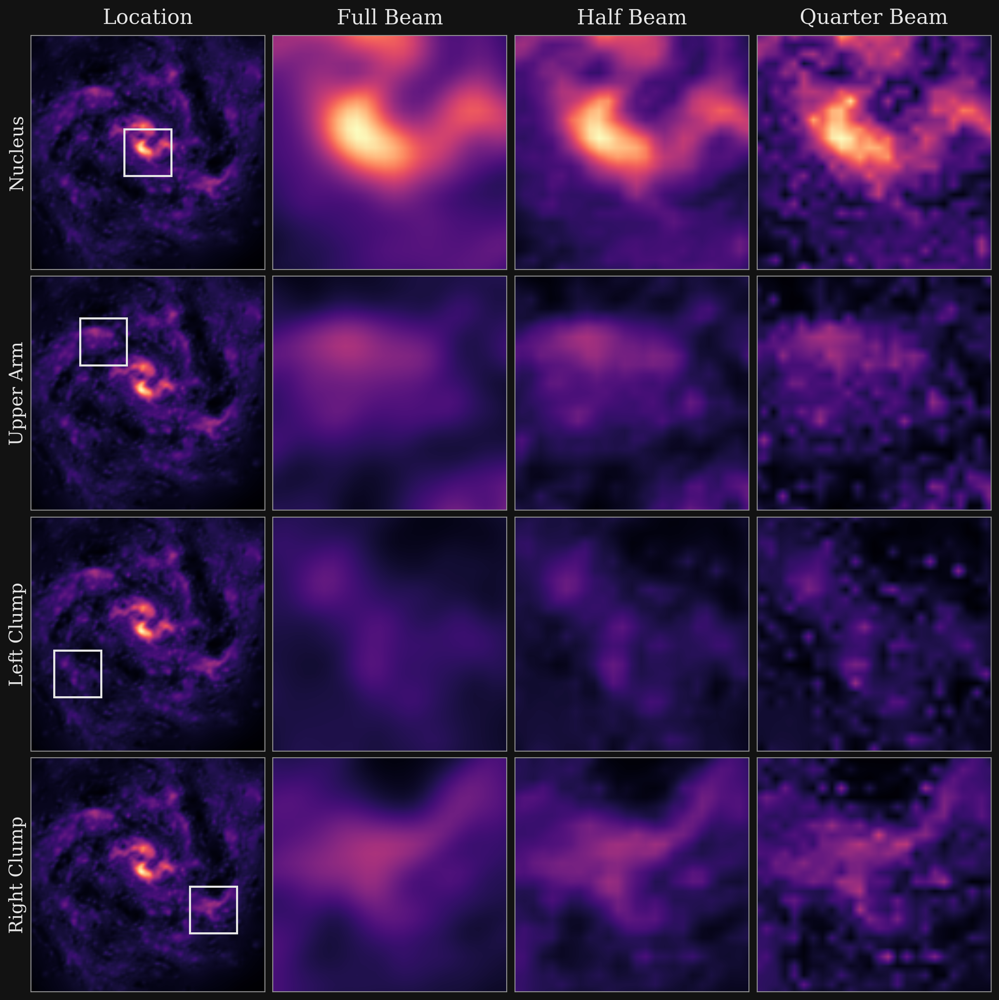

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(4, 4, figsize=(12, 12), constrained_layout=True)

for row, (region_name, cx, cy) in enumerate(REGIONS):
    ax_ctx = axes[row, 0]
    ax_ctx.imshow(norm_mom0["half"], origin="lower", extent=extent, cmap="magma",
                 vmin=0, vmax=100, interpolation="bilinear")
    ax_ctx.set_xlim(2.5, -2.5)
    ax_ctx.set_ylim(-2.5, 2.5)
    ax_ctx.set_xticks([])
    ax_ctx.set_yticks([])
    ax_ctx.set_box_aspect(1)
    for spine in ax_ctx.spines.values():
        spine.set_color(MUTED)
    box = Rectangle((cx - BOX_HALF, cy - BOX_HALF), 2 * BOX_HALF, 2 * BOX_HALF,
                    edgecolor=INK, facecolor="none", linewidth=1.8)
    ax_ctx.add_patch(box)
    if row == 0:
        ax_ctx.set_title("Location", fontsize=18, pad=10)
    ax_ctx.set_ylabel(region_name, fontsize=16)

    for col, (key, title) in enumerate(beam_cols, start=1):
        ax = axes[row, col]
        ax.imshow(norm_mom0[key], origin="lower", extent=extent, cmap="magma",
                 vmin=0, vmax=100, interpolation="bilinear")
        ax.set_xlim(cx + BOX_HALF, cx - BOX_HALF)
        ax.set_ylim(cy - BOX_HALF, cy + BOX_HALF)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_box_aspect(1)
        for spine in ax.spines.values():
            spine.set_color(MUTED)
        if row == 0:
            ax.set_title(title, fontsize=18, pad=10)

plt.show()

# Physical scale: scale bars in pc

NGC 7469 is at *D* = 71.2 Mpc (*z* = 0.01641; Izumi et al. 2020, ApJ 898,
75 -- the same NGC 7469 CO(2-1) ALMA target as this dataset), giving an
angular-diameter-distance scale of 1" = 334 pc. At this dataset's pixel
scale (`CELL_ARCSEC` = 0.04"), that's ~13.4 pc/pixel -- so the ~5" field of
view in the maps above is ~1.7 kpc across, and each 1" region cutout is
~330 pc across. The two figures below repeat the full/half/quarter-beam
moment-0 mosaic and one region cutout with the scale bar labeled in pc
instead of arcsec.

pixel scale: 13.36 pc/pixel


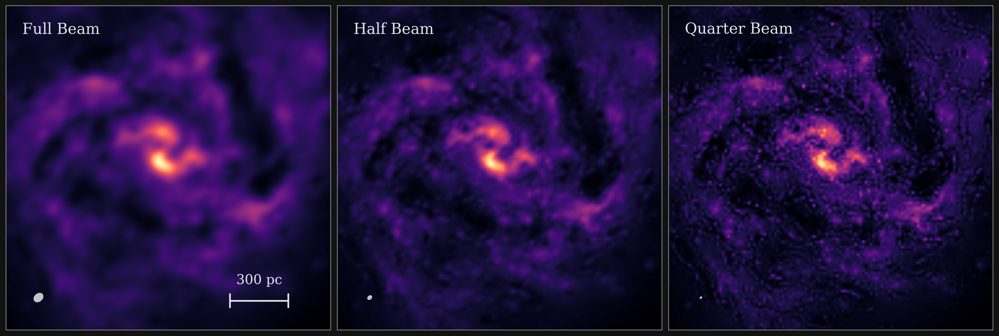

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# D = 71.2 Mpc (z = 0.01641), angular-diameter-distance scale from Izumi
# et al. 2020, ApJ 898, 75 -- same NGC 7469 CO(2-1) ALMA target as this
# dataset.
PC_PER_ARCSEC = 334.0
CELL_PC = CELL_ARCSEC * PC_PER_ARCSEC
print(f"pixel scale: {CELL_PC:.2f} pc/pixel")

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.5), constrained_layout=True)

panels = [("full", "Full Beam"), ("half", "Half Beam"), ("quarter", "Quarter Beam")]
for ax, (name, title) in zip(axes, panels):
    ax.imshow(norm_mom0[name], origin="lower", extent=extent, cmap="magma",
             vmin=norm_mom0[name].min(), vmax=norm_mom0[name].max(),
             interpolation="bilinear")
    ax.set_xlim(2.5, -2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(1)
    for spine in ax.spines.values():
        spine.set_color(MUTED)
    ax.text(0.05, 0.95, title, transform=ax.transAxes, ha="left", va="top",
           color=INK, fontsize=18)

    bm, bn = beams[name]
    beam_patch = Ellipse(BEAM_CENTER, width=bn, height=bm, angle=-bpa,
                         facecolor=INK, edgecolor="none", alpha=0.85)
    ax.add_patch(beam_patch)

# 300 pc scale bar -- same geometry/position as the 1" bar in the figure
# above, length converted via PC_PER_ARCSEC instead of fixed at 1".
bar_pc = 300.0
bar_len_arcsec = bar_pc / PC_PER_ARCSEC
bar_x_center, bar_y = -1.4, -2.05
bar_half_len, cap_half_h, label_pad = bar_len_arcsec / 2.0, 0.10, 0.22
x0, x1 = bar_x_center - bar_half_len, bar_x_center + bar_half_len

ax_bar = axes[0]
ax_bar.plot([x0, x1], [bar_y, bar_y], color=INK, linewidth=2, solid_capstyle="butt")
ax_bar.plot([x0, x0], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax_bar.plot([x1, x1], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax_bar.text(bar_x_center, bar_y + label_pad, f"{bar_pc:.0f} pc", color=INK,
           ha="center", va="bottom", fontsize=16)

plt.show()

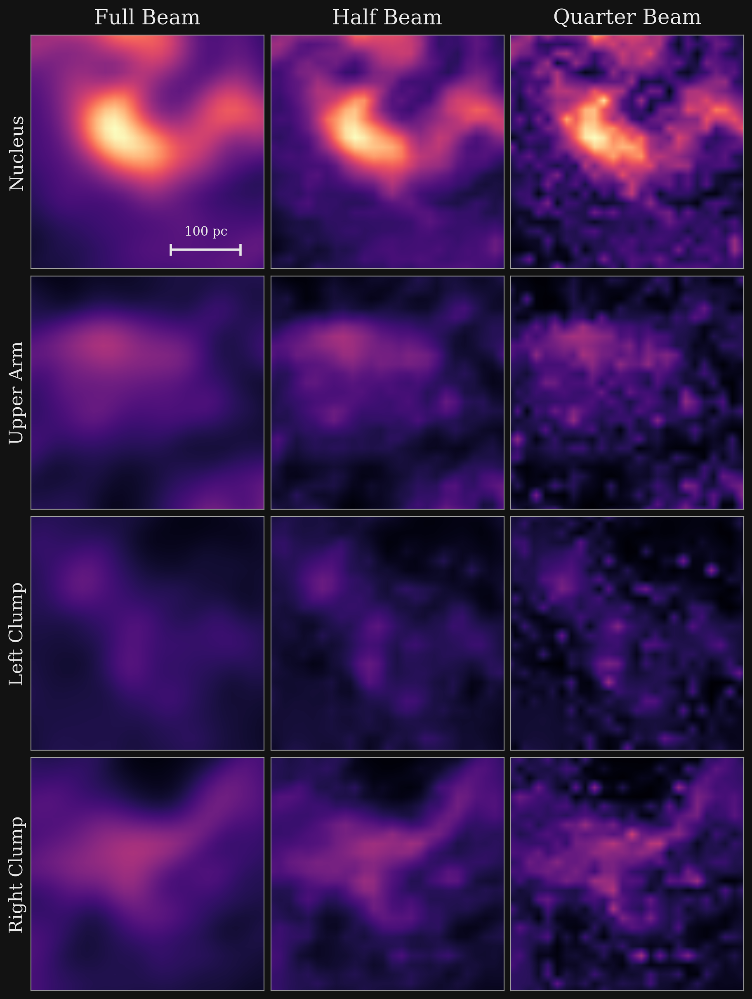

In [11]:
import matplotlib.pyplot as plt

bar_pc_cutout = 100.0
bar_len_arcsec_cutout = bar_pc_cutout / PC_PER_ARCSEC

fig, axes = plt.subplots(4, 3, figsize=(9, 12), constrained_layout=True)

for row, (region_name, cx, cy) in enumerate(REGIONS):
    for col, (key, title) in enumerate(beam_cols):
        ax = axes[row, col]
        ax.imshow(norm_mom0[key], origin="lower", extent=extent, cmap="magma",
                 vmin=0, vmax=100, interpolation="bilinear")
        ax.set_xlim(cx + BOX_HALF, cx - BOX_HALF)
        ax.set_ylim(cy - BOX_HALF, cy + BOX_HALF)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_box_aspect(1)
        for spine in ax.spines.values():
            spine.set_color(MUTED)
        if row == 0:
            ax.set_title(title, fontsize=18, pad=10)
        if col == 0:
            ax.set_ylabel(region_name, fontsize=16)

# 100 pc scale bar in the Nucleus/Full-beam panel's bottom-right corner
# (positive x is visually leftward here too, same RA-flip as the maps
# above).
ax0 = axes[0, 0]
cx0, cy0 = REGIONS[0][1], REGIONS[0][2]
bar_x_center = cx0 - BOX_HALF + 0.10 + bar_len_arcsec_cutout / 2.0
bar_y = cy0 - BOX_HALF + 0.08
bar_half_len, cap_half_h = bar_len_arcsec_cutout / 2.0, 0.02
x0b, x1b = bar_x_center - bar_half_len, bar_x_center + bar_half_len
ax0.plot([x0b, x1b], [bar_y, bar_y], color=INK, linewidth=2, solid_capstyle="butt")
ax0.plot([x0b, x0b], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax0.plot([x1b, x1b], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax0.text(bar_x_center, bar_y + cap_half_h + 0.03, f"{bar_pc_cutout:.0f} pc",
        color=INK, ha="center", va="bottom", fontsize=11)

plt.show()

# 2 kpc x 2 kpc crop centered on the nucleus

The full gridded image is 320 x 320 px at `CELL_ARCSEC` = 0.04" (12.8" x
12.8" $\approx$ 4.3 kpc across); the maps above crop that to a 5" x 5"
($\approx$ 1.7 kpc) view. Here the full/half/quarter-beam mosaic is
re-cropped to a physically fixed 2 kpc x 2 kpc frame centered on the
nucleus (0, 0), converting the half-width from kpc to arcsec via
`PC_PER_ARCSEC` so the frame size in kpc stays exact.

2 kpc x 2 kpc frame = 5.988" x 5.988"


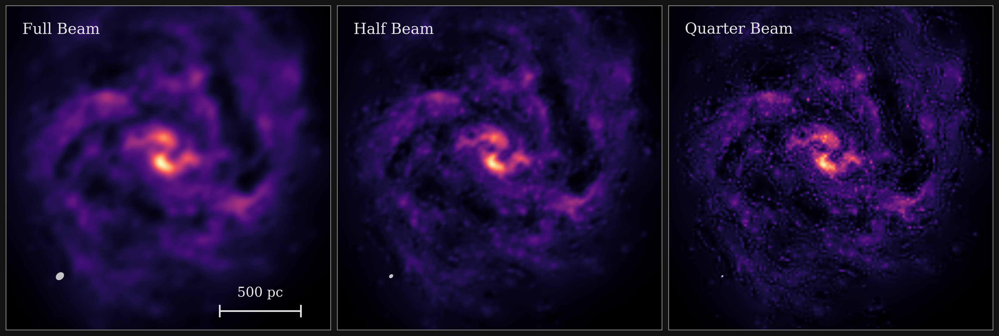

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

HALF_FOV_KPC = 1.0                                  # 2 kpc x 2 kpc frame
HALF_FOV_ARCSEC = HALF_FOV_KPC * 1000.0 / PC_PER_ARCSEC
print(f"2 kpc x 2 kpc frame = {2 * HALF_FOV_ARCSEC:.3f}\" x {2 * HALF_FOV_ARCSEC:.3f}\"")

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.5), constrained_layout=True)

panels = [("full", "Full Beam"), ("half", "Half Beam"), ("quarter", "Quarter Beam")]
for ax, (name, title) in zip(axes, panels):
    ax.imshow(norm_mom0[name], origin="lower", extent=extent, cmap="magma",
             vmin=norm_mom0[name].min(), vmax=norm_mom0[name].max(),
             interpolation="bilinear")
    ax.set_xlim(HALF_FOV_ARCSEC, -HALF_FOV_ARCSEC)
    ax.set_ylim(-HALF_FOV_ARCSEC, HALF_FOV_ARCSEC)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(1)
    for spine in ax.spines.values():
        spine.set_color(MUTED)
    ax.text(0.05, 0.95, title, transform=ax.transAxes, ha="left", va="top",
           color=INK, fontsize=18)

    bm, bn = beams[name]
    beam_patch = Ellipse(BEAM_CENTER, width=bn, height=bm, angle=-bpa,
                         facecolor=INK, edgecolor="none", alpha=0.85)
    ax.add_patch(beam_patch)

# 500 pc scale bar in the bottom-right corner of the frame (positive x is
# visually leftward, same RA-flip as the maps above).
bar_pc = 500.0
bar_len_arcsec = bar_pc / PC_PER_ARCSEC
bar_x_center = -HALF_FOV_ARCSEC + 0.55 + bar_len_arcsec / 2.0
bar_y = -HALF_FOV_ARCSEC + 0.35
bar_half_len, cap_half_h, label_pad = bar_len_arcsec / 2.0, 0.10, 0.22
x0, x1 = bar_x_center - bar_half_len, bar_x_center + bar_half_len

ax_bar = axes[0]
ax_bar.plot([x0, x1], [bar_y, bar_y], color=INK, linewidth=2, solid_capstyle="butt")
ax_bar.plot([x0, x0], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax_bar.plot([x1, x1], [bar_y - cap_half_h, bar_y + cap_half_h], color=INK, linewidth=2)
ax_bar.text(bar_x_center, bar_y + label_pad, f"{bar_pc:.0f} pc", color=INK,
           ha="center", va="bottom", fontsize=16)

plt.show()